In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
from rise.rise import RISE
from rise.brise import B_RISE
import rise.utils as utils
from rise.utils import IMAGES

## MNSIT DATA

### Load Data and Train Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [3]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)      # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)      # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
model = MNISTCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2319
Epoch 2, Loss: 0.0599
Epoch 3, Loss: 0.0409


In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.9854


In [6]:
def build_digit_example_dict(model, loader, device, max_samples=100):
    model.eval()

    digit_dict = {d: [] for d in range(10)}
    seen = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(len(x)):
                seen += 1
                digit = y[i].item()

                if preds[i] == y[i]:  # only correct predictions
                    digit_dict[digit].append((x[i:i+1], y[i:i+1]))

                if seen >= max_samples:
                    break

            if seen >= max_samples:
                break

    return digit_dict

In [7]:
examples = build_digit_example_dict(model, test_loader, device)

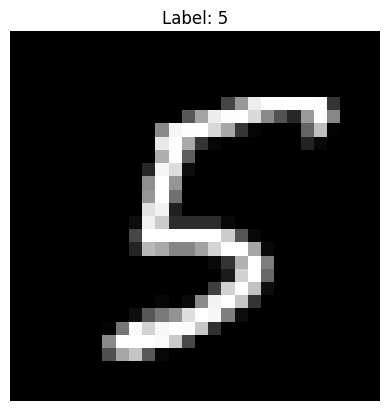

In [8]:
img_x, label = examples[5][2]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [22]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [23]:
sal = rise_banzhaf.forward(img_x, K=10, no_shift=True)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 617.56it/s]

Total forward passes: 11000


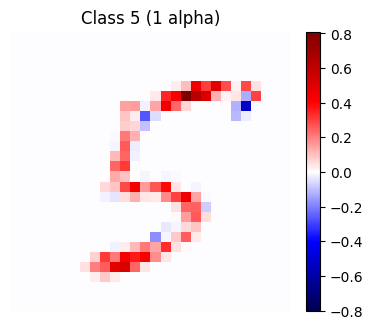

In [24]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 1)

In [19]:
rise = RISE(model, img_x)
rise.generate_masks(N=7000, s=28, p=0.1, no_shift=True)

Generating filters: 100%|██████████| 7000/7000 [00:00<00:00, 15684.24it/s]


In [20]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 70/70 [00:00<00:00, 1073.14it/s]


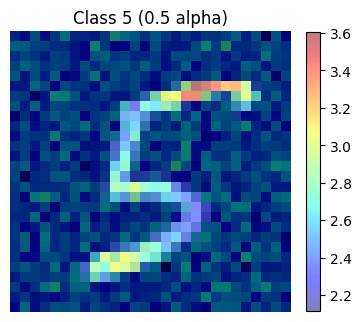

In [21]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=5, norm_mode="minmax", alpha = 0.5)

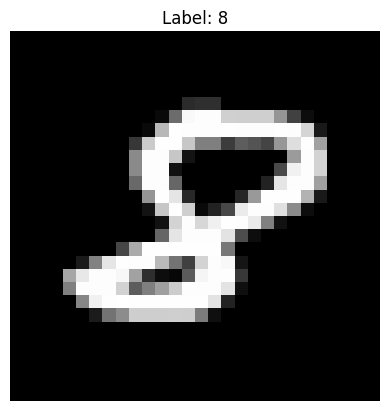

In [ ]:
img_x, label = examples[8][0]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [ ]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [ ]:
sal = rise_banzhaf.forward(img_x, K=10)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 567.03it/s]

Total forward passes: 11000


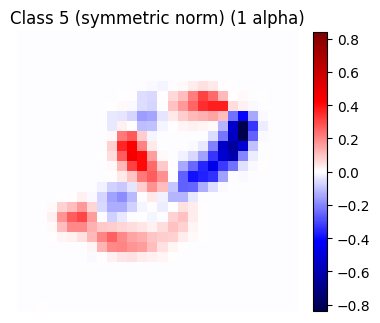

In [ ]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 1)

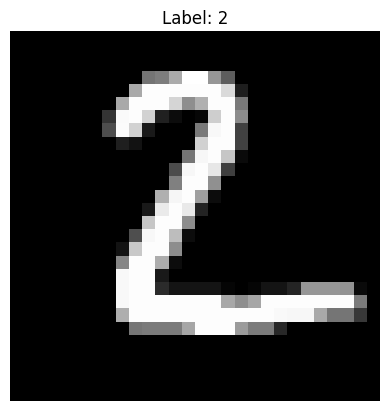

In [25]:
img_x, label = examples[2][0]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [26]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [30]:
sal = rise_banzhaf.forward(img_x, K=10, no_shift=True)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 620.34it/s]

Total forward passes: 11000


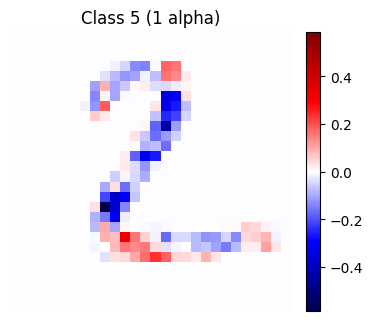

In [31]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 1)

## Exact Banzhaf

In [ ]:
from rise.exact_banzhaf import build_supergrid_mask, exact_banzhaf_supergrid

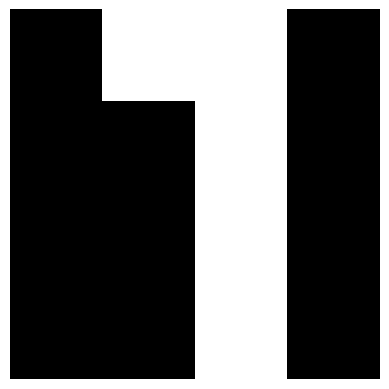

In [ ]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0]), 4))

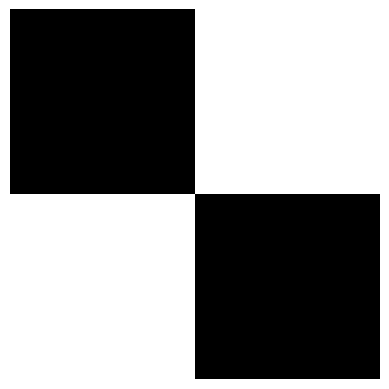

In [ ]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1, 
                                                   1,0]), 2))

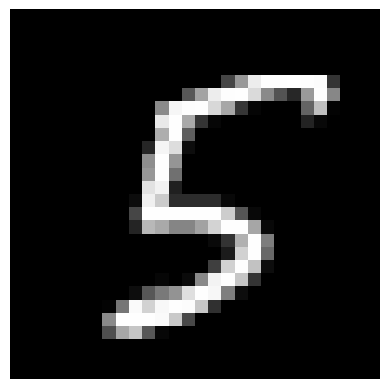

In [ ]:
plt.imshow(img_x.cpu().squeeze().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
model(img_x) # should be class 1 with high confidence, it is..

tensor([[ -1.8808, -10.8712,  -5.7817,  -0.9549,  -6.6322,  15.5278,   3.1611,
          -8.8254,  -0.2007,   2.4038]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [ ]:
beta = exact_banzhaf_supergrid(model, img_x, s=4)

Computing Banzhaf: 100%|██████████| 16/16 [00:27<00:00,  1.74s/it]


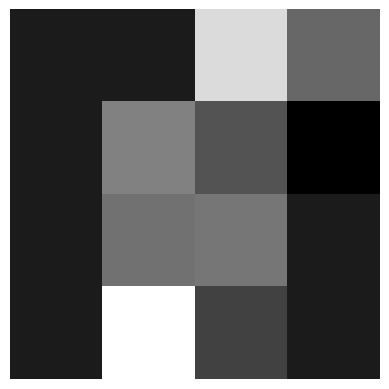

In [ ]:
utils.draw_mask(beta[5])

In [ ]:
beta[5]

tensor([[ 0.0000e+00,  1.0729e-03,  3.4611e+00,  1.3786e+00],
        [ 0.0000e+00,  1.8455e+00,  1.0175e+00, -4.9269e-01],
        [ 0.0000e+00,  1.5767e+00,  1.6469e+00,  0.0000e+00],
        [ 0.0000e+00,  4.1165e+00,  7.1269e-01,  0.0000e+00]], device='cuda:0')

In [ ]:
# do banzhaf approx
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=4, p=0.5, mode="nearest")

In [ ]:
sal = rise_banzhaf.forward(img_x, no_shift=True)

Estimated forward passes: 9000.0


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 767.92it/s]

Total forward passes: 8947


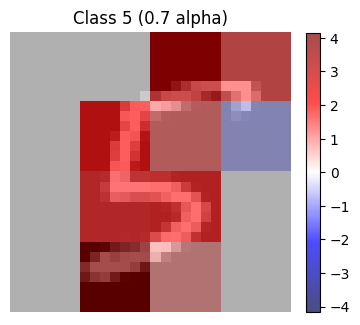

In [ ]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 0.7)

In [ ]:
beta[5]

tensor([[ 0.0000e+00,  1.0729e-03,  3.4611e+00,  1.3786e+00],
        [ 0.0000e+00,  1.8455e+00,  1.0175e+00, -4.9269e-01],
        [ 0.0000e+00,  1.5767e+00,  1.6469e+00,  0.0000e+00],
        [ 0.0000e+00,  4.1165e+00,  7.1269e-01,  0.0000e+00]], device='cuda:0')

In [ ]:
brise_estimate = sal_map_brise.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(brise_estimate)

[[-0.0002  0.0016  3.2549  1.2838]
 [-0.0002  1.8682  0.9866 -0.5413]
 [-0.0002  1.6038  1.6844 -0.0002]
 [-0.0001  4.1534  0.7146 -0.0002]]


Try with p != 0.5

In [ ]:
# do banzhaf approx
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=4, p=0.8, mode="nearest")

In [ ]:
sal = rise_banzhaf.forward(img_x, no_shift=True)

Estimated forward passes: 4199.999999999999


Banzhaf sampling: 100%|██████████| 1000/1000 [00:00<00:00, 1056.76it/s]

Total forward passes: 4138


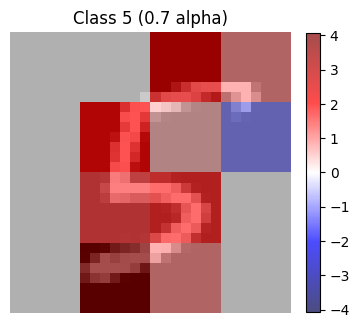

In [ ]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 0.7)

In [ ]:
brise_estimate = sal_map_brise.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(brise_estimate)

[[-0.0003 -0.0003  2.5661  0.8614]
 [-0.0003  1.9476  0.5393 -0.8975]
 [-0.0002  1.4437  1.6773 -0.0003]
 [-0.0003  4.0721  0.8786 -0.0003]]


In [ ]:
rise = RISE(model, img_x)
rise.generate_masks(N=10000, s=4, p=0.5, mode="nearest", no_shift=True)

Generating filters: 100%|██████████| 10000/10000 [00:00<00:00, 16274.14it/s]


In [ ]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 100/100 [00:00<00:00, 492.19it/s]


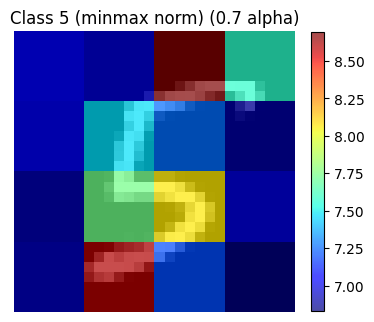

In [ ]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=5, norm_mode="minmax", alpha = 0.7)

In [ ]:
rise_estimate = sal_map_rise.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(rise_estimate)

[[7.0435 6.9728 8.6899 7.5837]
 [7.0218 7.4703 7.2582 6.8891]
 [6.912  7.7311 8.0639 6.9812]
 [6.9364 8.6093 7.2064 6.8284]]


In [ ]:
from scipy.stats import pearsonr

print("Pearson correlation Banzhaf & BRise:", pearsonr(beta[5].cpu().numpy().flatten(), brise_estimate.flatten())[0])
print("Pearson correlation Banzhaf & RISE:", pearsonr(beta[5].cpu().numpy().flatten(), rise_estimate.flatten())[0])

Pearson correlation Banzhaf & BRise: 0.99776614
Pearson correlation Banzhaf & RISE: 0.9935137


It is not a Lynx